In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [2]:
df_debt = pd.read_csv("Debt_Data.csv", encoding = 'latin1')

In [3]:
df_country = pd.read_csv("Country_Details.csv", encoding = 'latin1')

In [4]:
df_indicator = pd.read_csv("Indicator_Details.csv", encoding = 'latin1')

In [5]:
df_debt

,Country Code,Series Code,Year,Value
0,ALB,DT.GPA.DPPG,2000,1.054540e+01
1,ALB,DT.GPA.OFFT,2000,1.054540e+01
2,ALB,DT.GPA.PRVT,2000,0.000000e+00
3,ALB,DT.GRE.DPPG,2000,2.576090e+01
4,ALB,DT.GRE.OFFT,2000,2.576090e+01
...,...,...,...,...
1050747,ZWE,DT.UND.OFFT.CD,2024,6.881084e+08
1050748,ZWE,DT.UND.PRVT.CD,2024,6.350490e+06
1050749,ZWE,DT.UND.DPPG.CD,2024,6.944589e+08
1050750,ZWE,DT.DOD.DIMF.US.CD,2024,0.000000e+00


In [6]:
df_country

,Country Name,Code,Income Group,Region,Lending category,Is_HIPC
0,Afghanistan,AFG,Low income,Middle East & North Africa,IDA,Yes
1,Albania,ALB,Upper middle income,Europe & Central Asia,IBRD,No
2,Algeria,DZA,Upper middle income,Middle East & North Africa,IBRD,No
3,Angola,AGO,Lower middle income,Sub-Saharan Africa,IBRD,No
4,Argentina,ARG,Upper middle income,Latin America & Caribbean,IBRD,No
...,...,...,...,...,...,...
114,Vanuatu,VUT,Lower middle income,East Asia & Pacific,IDA,No
115,Viet Nam,VNM,Lower middle income,East Asia & Pacific,IBRD,No
116,"Yemen, Republic of",YEM,Low income,Middle East & North Africa,IDA,No
117,Zambia,ZMB,Lower middle income,Sub-Saharan Africa,IDA,Yes


In [7]:
df_indicator

,Series Code,Indicator Name
0,DT.GPA.DPPG,Average grace period on new external debt comm...
1,DT.GPA.OFFT,Average grace period on new external debt comm...
2,DT.GPA.PRVT,Average grace period on new external debt comm...
3,DT.GRE.DPPG,Average grant element on new external debt com...
4,DT.GRE.OFFT,Average grant element on new external debt com...
...,...,...
571,DT.AMT.PBND.PRVG.CD,"PRVG, bonds (AMT, current US$)"
572,DT.NFL.PBND.PRVG.CD,"PRVG, bonds (NFL, current US$)"
573,DT.DOD.PVLX.CD,Present value of external debt (current US$)
574,DT.DOD.PVLX.EX.ZS,"Present value of debt (% of exports of goods, ..."


In [8]:
df_country = df_country.rename(columns = {"Code" :"Country Code"})

In [9]:
df_country

,Country Name,Country Code,Income Group,Region,Lending category,Is_HIPC
0,Afghanistan,AFG,Low income,Middle East & North Africa,IDA,Yes
1,Albania,ALB,Upper middle income,Europe & Central Asia,IBRD,No
2,Algeria,DZA,Upper middle income,Middle East & North Africa,IBRD,No
3,Angola,AGO,Lower middle income,Sub-Saharan Africa,IBRD,No
4,Argentina,ARG,Upper middle income,Latin America & Caribbean,IBRD,No
...,...,...,...,...,...,...
114,Vanuatu,VUT,Lower middle income,East Asia & Pacific,IDA,No
115,Viet Nam,VNM,Lower middle income,East Asia & Pacific,IBRD,No
116,"Yemen, Republic of",YEM,Low income,Middle East & North Africa,IDA,No
117,Zambia,ZMB,Lower middle income,Sub-Saharan Africa,IDA,Yes


In [10]:
# 1. Merge Debt Data with Country Metadata
df_merged = pd.merge(df_debt, df_country, on='Country Code', how='left')

# 2. Merge with Indicator/Series Metadata
df_merged = pd.merge(df_merged, df_indicator, on='Series Code', how='left')

# Convert columns to correct data types
df_merged['Year'] = df_merged['Year'].astype(int)
df_merged['Value'] = pd.to_numeric(df_merged['Value'], errors='coerce')

In [11]:
df_merged

,Country Code,Series Code,Year,Value,Country Name,Income Group,Region,Lending category,Is_HIPC,Indicator Name
0,ALB,DT.GPA.DPPG,2000,1.054540e+01,Albania,Upper middle income,Europe & Central Asia,IBRD,No,Average grace period on new external debt comm...
1,ALB,DT.GPA.OFFT,2000,1.054540e+01,Albania,Upper middle income,Europe & Central Asia,IBRD,No,Average grace period on new external debt comm...
2,ALB,DT.GPA.PRVT,2000,0.000000e+00,Albania,Upper middle income,Europe & Central Asia,IBRD,No,Average grace period on new external debt comm...
3,ALB,DT.GRE.DPPG,2000,2.576090e+01,Albania,Upper middle income,Europe & Central Asia,IBRD,No,Average grant element on new external debt com...
4,ALB,DT.GRE.OFFT,2000,2.576090e+01,Albania,Upper middle income,Europe & Central Asia,IBRD,No,Average grant element on new external debt com...
...,...,...,...,...,...,...,...,...,...,...
1050747,ZWE,DT.UND.OFFT.CD,2024,6.881084e+08,Zimbabwe,Lower middle income,Sub-Saharan Africa,Blend,No,"Undisbursed external debt, official creditors ..."
1050748,ZWE,DT.UND.PRVT.CD,2024,6.350490e+06,Zimbabwe,Lower middle income,Sub-Saharan Africa,Blend,No,"Undisbursed external debt, private creditors (..."
1050749,ZWE,DT.UND.DPPG.CD,2024,6.944589e+08,Zimbabwe,Lower middle income,Sub-Saharan Africa,Blend,No,"Undisbursed external debt, total (UND, current..."
1050750,ZWE,DT.DOD.DIMF.US.CD,2024,0.000000e+00,Zimbabwe,Lower middle income,Sub-Saharan Africa,Blend,No,"Use of IMF credit (DOD, current US$)"


In [12]:
df_merged.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050752 entries, 0 to 1050751
Data columns (total 10 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Country Code      1050752 non-null  object 
 1   Series Code       1050752 non-null  object 
 2   Year              1050752 non-null  int64  
 3   Value             1050752 non-null  float64
 4   Country Name      1050752 non-null  object 
 5   Income Group      1050752 non-null  object 
 6   Region            1050752 non-null  object 
 7   Lending category  1050752 non-null  object 
 8   Is_HIPC           1050752 non-null  object 
 9   Indicator Name    1050752 non-null  object 
dtypes: float64(1), int64(1), object(8)
memory usage: 80.2+ MB


In [13]:
df_merged['Year'] = df_merged['Year'].astype(str)

In [14]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050752 entries, 0 to 1050751
Data columns (total 10 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Country Code      1050752 non-null  object 
 1   Series Code       1050752 non-null  object 
 2   Year              1050752 non-null  object 
 3   Value             1050752 non-null  float64
 4   Country Name      1050752 non-null  object 
 5   Income Group      1050752 non-null  object 
 6   Region            1050752 non-null  object 
 7   Lending category  1050752 non-null  object 
 8   Is_HIPC           1050752 non-null  object 
 9   Indicator Name    1050752 non-null  object 
dtypes: float64(1), object(9)
memory usage: 80.2+ MB


In [15]:
df_merged.describe()

,Value
count,1.050752e+06
mean,2.218379e+09
std,6.043035e+10
min,-4.450000e+11
25%,0.000000e+00
50%,1.022044e+07
75%,2.100024e+08
max,1.860000e+13


In [16]:
df_merged['Is_HIPC'].value_counts()


Is_HIPC
No     729881
Yes    320871
Name: count, dtype: int64

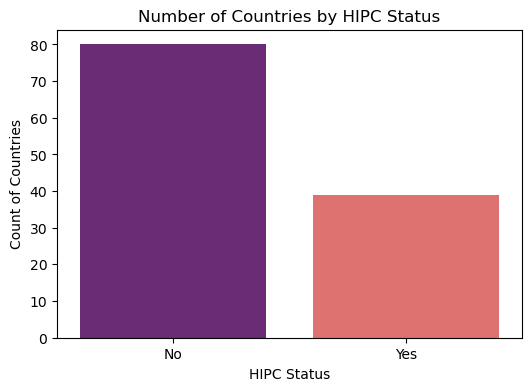

In [25]:
df_unique = df_merged.drop_duplicates(subset=['Country Code'])

plt.figure(figsize=(6,4))
sns.countplot(x='Is_HIPC', data=df_unique, palette = 'magma')
plt.title("Number of Countries by HIPC Status")
plt.xlabel("HIPC Status")
plt.ylabel("Count of Countries")
plt.show()
warnings.filterwarnings("ignore", category=FutureWarning)

In [18]:
df_merged.groupby('Region')['Value'].sum()


Region
East Asia & Pacific           8.800197e+14
Europe & Central Asia         2.573784e+14
Latin America & Caribbean     5.700321e+14
Middle East & North Africa    1.758339e+14
South Asia                    2.323271e+14
Sub-Saharan Africa            2.153750e+14
Name: Value, dtype: float64

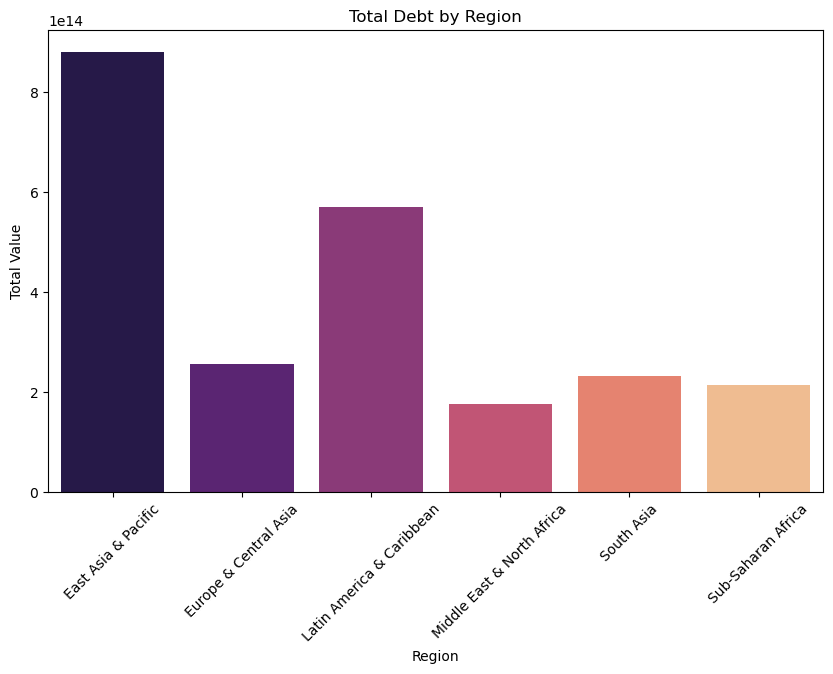

In [19]:
region_values = df_merged.groupby('Region', as_index=False)['Value'].sum()

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x='Region', y='Value', data=region_values, palette = 'magma')
plt.xticks(rotation=45)
plt.title("Total Debt by Region")
plt.ylabel("Total Value")
plt.xlabel("Region")
plt.show()

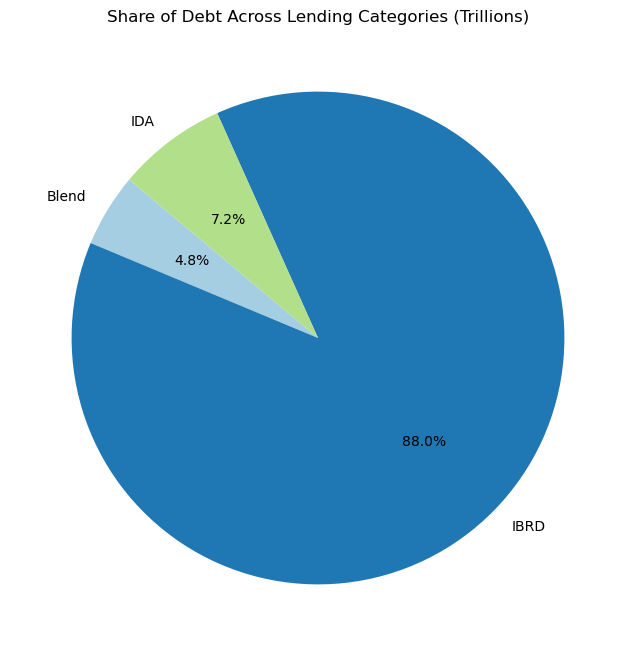

In [20]:
import matplotlib.pyplot as plt

# Aggregate debt values by Lending category
lending_values = df_merged.groupby('Lending category', as_index=False)['Value'].sum()

# Convert to trillions for readability
lending_values['Value_Trillions'] = lending_values['Value'] / 1e12

# Plot pie chart
plt.figure(figsize=(8,8))
plt.pie(lending_values['Value_Trillions'], 
        labels=lending_values['Lending category'], 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=plt.cm.Paired.colors)

plt.title("Share of Debt Across Lending Categories (Trillions)")
plt.show()


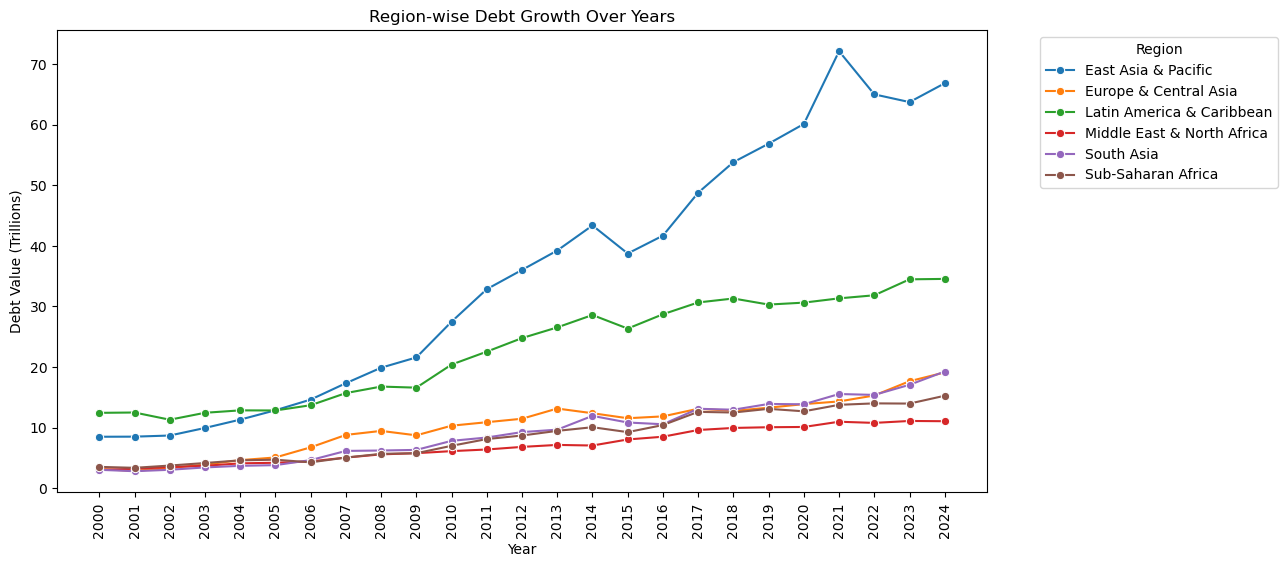

In [21]:
# Scale values into trillions for readability
df_merged['Value_Trillions'] = df_merged['Value'] / 1e12

# Aggregate by Region and Year
region_trends = df_merged.groupby(['Region','Year'], as_index=False)['Value_Trillions'].sum()

plt.figure(figsize=(12,6))
sns.lineplot(data=region_trends, x='Year', y='Value_Trillions', hue='Region', marker='o')

plt.title("Region-wise Debt Growth Over Years")
plt.xlabel("Year")
plt.xticks(rotation=90)
plt.ylabel("Debt Value (Trillions)")
plt.legend(title="Region", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

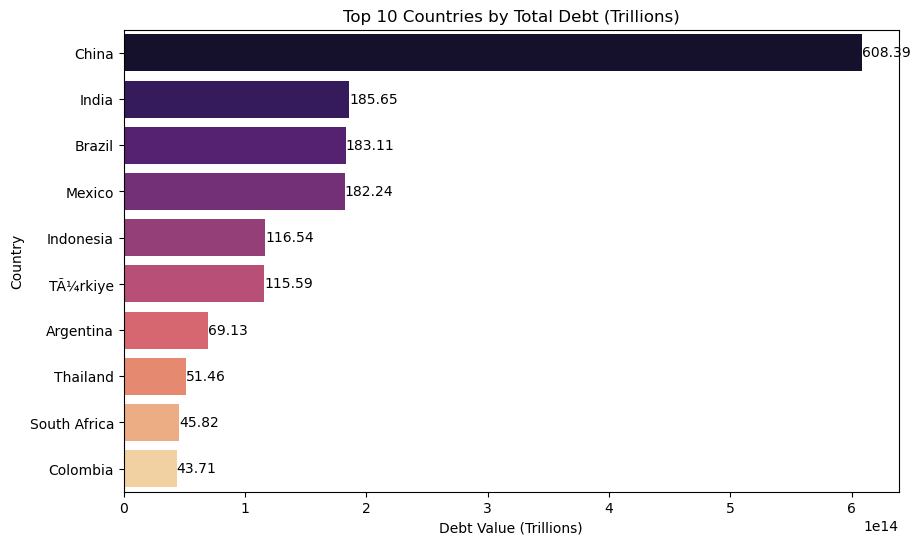

In [22]:
# Aggregate totals
country_totals = df_merged.groupby('Country Name', as_index=False)['Value'].sum()

# Sort and take top 10
top10 = country_totals.sort_values('Value', ascending=False).head(10)

plt.figure(figsize=(10,6))
ax = sns.barplot(x='Value', y='Country Name', data=top10, palette='magma')

# Add labels
for p in ax.patches:
    val = p.get_width()
    ax.annotate(f'{val/1e12:.2f}', 
                (val, p.get_y() + p.get_height()/2.), 
                ha='left', va='center')

plt.title("Top 10 Countries by Total Debt (Trillions)")
plt.xlabel("Debt Value (Trillions)")
plt.ylabel("Country")
plt.show()
warnings.filterwarnings("ignore", category=FutureWarning)

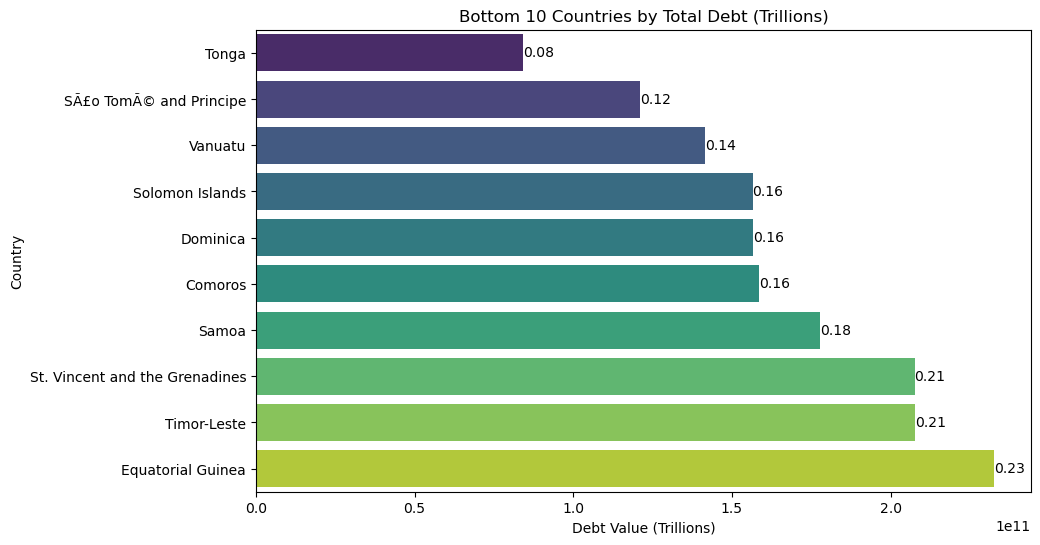

In [23]:
bottom10 = country_totals.sort_values('Value', ascending=True).head(10)

plt.figure(figsize=(10,6))
ax = sns.barplot(x='Value', y='Country Name', data=bottom10, palette='viridis')

# Add labels on bars
for p in ax.patches:
    val = p.get_width()
    ax.annotate(f'{val/1e12:.2f}', 
                (val, p.get_y() + p.get_height()/2.), 
                ha='left', va='center')

plt.title("Bottom 10 Countries by Total Debt (Trillions)")
plt.xlabel("Debt Value (Trillions)")
plt.ylabel("Country")
plt.show()
warnings.filterwarnings("ignore", category=FutureWarning)


In [24]:
df_merged['Value_Trillions'] = df_merged['Value'] / 1e12
df_merged['Value_Trillions'].describe()


count    1.050752e+06
mean     2.218379e-03
std      6.043035e-02
min     -4.450000e-01
25%      0.000000e+00
50%      1.022044e-05
75%      2.100024e-04
max      1.860000e+01
Name: Value_Trillions, dtype: float64

In [ ]:
pivot_df = df_merged.pivot_table(index=['Country Name','Year'],
                                 columns='Indicator Name',
                                 values='Value')
corr = pivot_df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Between Debt Indicators")
plt.show()


In [29]:
# Aggregate debt values by Series Code
series_values = df_merged.groupby(['Series Code','Indicator Name'], as_index=False)['Value'].sum()

# Convert to trillions for readability
series_values['Value_Trillions'] = series_values['Value'] / 1e12

# Top 10 Series Codes by debt
top10_series = series_values.sort_values('Value', ascending=False).head(10)

print(top10_series[['Series Code','Indicator Name','Value_Trillions']])


        Series Code                                     Indicator Name  \
574  NY.GNP.MKTP.CD                                  GNI (current US$)   
0    BM.GSR.TOTL.CD  Imports of goods, services and primary income ...   
4    BX.GSR.TOTL.CD  Exports of goods, services and primary income ...   
186  DT.DOD.DECT.CD     External debt stocks, total (DOD, current US$)   
571  FI.RES.TOTL.CD        Total reserves (includes gold, current US$)   
195  DT.DOD.DLXF.CD  External debt stocks, long-term (DOD, current ...   
258  DT.DOD.VTOT.CD  External debt stocks, variable rate (DOD, curr...   
198  DT.DOD.DPPG.CD  External debt stocks, public and publicly guar...   
252  DT.DOD.PUBS.CD  External debt stocks, long-term public sector ...   
192  DT.DOD.DEPS.CD  External debt stocks, public sector (PPG) (DOD...   

     Value_Trillions  
574       507.523660  
0         136.954630  
4         129.836297  
186       125.146295  
571       107.051051  
195        89.221490  
258        55.486325  
1

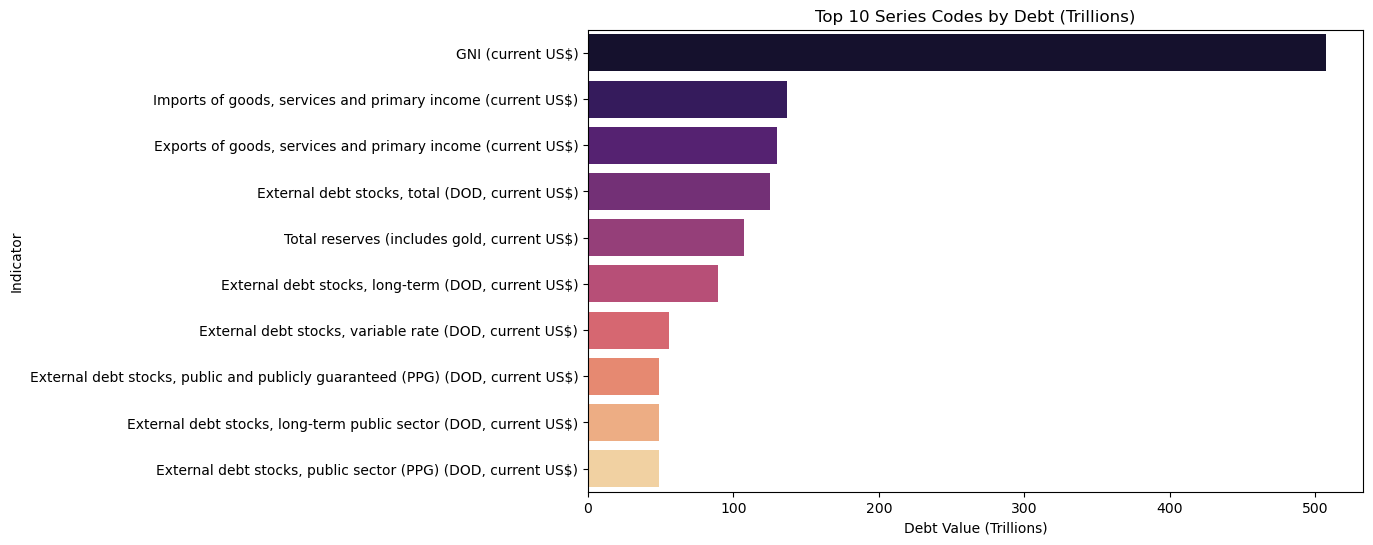

In [30]:
plt.figure(figsize=(10,6))
sns.barplot(x='Value_Trillions', y='Indicator Name', 
            data=top10_series, palette='magma')
plt.title("Top 10 Series Codes by Debt (Trillions)")
plt.xlabel("Debt Value (Trillions)")
plt.ylabel("Indicator")
plt.show()



In [31]:
# Aggregate debt values by Series Code
series_values = df_merged.groupby(['Series Code','Indicator Name'], as_index=False)['Value'].sum()

# Convert to trillions for readability
series_values['Value_Trillions'] = series_values['Value'] / 1e12

# Bottom 10 Series Codes by debt
bottom10_series = series_values.sort_values('Value', ascending=True).head(10)

print(bottom10_series[['Series Code','Indicator Name','Value_Trillions']])


                        Series Code  \
101                  DT.DFR.DPPG.CD   
468              DT.NTR.OFFT.OPS.CD   
432                  DT.NTR.BLAT.CD   
434              DT.NTR.BLAT.OPS.CD   
436               DT.NTR.BLAT.PS.CD   
486                  DT.NTR.PROP.CD   
490               DT.NTR.PROP.PS.CD   
487               DT.NTR.PROP.GG.CD   
492  DT.NTR.PRVT.CB.CD                
456              DT.NTR.MLAT.OPS.CD   

                                      Indicator Name  Value_Trillions  
101      Debt forgiveness or reduction (current US$)        -0.258794  
468       OPS, official creditors (NTR, current US$)        -0.057851  
432                PPG, bilateral (NTR, current US$)        -0.039467  
434                OPS, bilateral (NTR, current US$)        -0.039245  
436                 PS, bilateral (NTR, current US$)        -0.037240  
486  PPG, other private creditors (NTR, current US$)        -0.035094  
490   PS, other private creditors (NTR, current US$)        -0.034

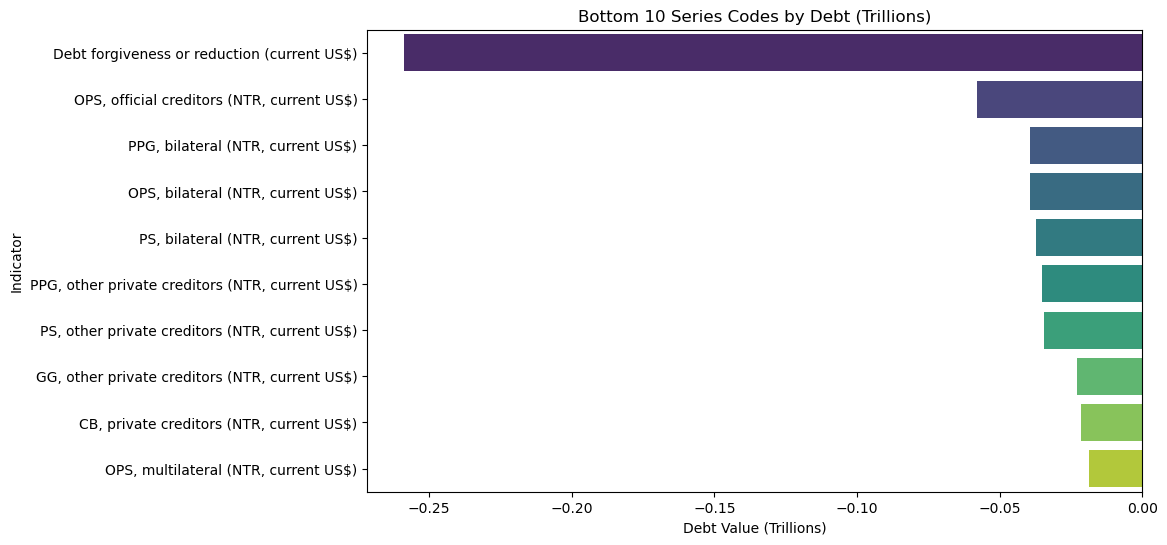

In [32]:
plt.figure(figsize=(10,6))
sns.barplot(x='Value_Trillions', y='Indicator Name', 
            data=bottom10_series, palette='viridis')
plt.title("Bottom 10 Series Codes by Debt (Trillions)")
plt.xlabel("Debt Value (Trillions)")
plt.ylabel("Indicator")
plt.show()


In [42]:
df_merged.to_csv('merged_data.csv',index = False)